# Stratification process

In [3]:
import datetime
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Install: pip install iterative-stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from scipy.stats import chi2_contingency, kruskal
# Convert strat_key to one-hot encoding for multi-label stratification
from sklearn.preprocessing import MultiLabelBinarizer

In [4]:
lits = pd.read_csv("../files/stats/lits/per_case_summary.csv")

## Visualise

In [5]:
lits.tail()

,case_name,image_shape,label_shape,ct_min,ct_max,spacing_x,spacing_y,spacing_z,affine_codes,unique_labels,...,num_lesions,lesion_volumes_ml,lesion_equiv_diameters_mm,min_lesion_diameter_mm,max_lesion_diameter_mm,mean_lesion_diameter_mm,liver_texture_variance,liver_noise_estimate,status,obs
126,volume-95.nii.gz,"(512, 512, 841)","(512, 512, 841)",-10522.0,27572.0,0.738000,0.738000,0.800000,"('L', 'P', 'S')",0;1;2,...,3,1.1219665827761545;0.0008714303555542947;0.001...,12.892201948471337;1.1850718641721716;1.493096...,1.185072,12.892202,5.190124,933.917696,25.925926,success,NaN
127,volume-96.nii.gz,"(512, 512, 722)","(512, 512, 722)",-1024.0,1789.0,0.746094,0.746094,0.700000,"('L', 'P', 'S')",0;1;2,...,23,0.1628775088228922;0.4882428673566601;0.036627...,6.775699942821541;9.769652019236547;4.12038713...,4.120387,21.902136,9.254127,1192.921630,33.333333,success,NaN
128,volume-97.nii.gz,"(512, 512, 671)","(512, 512, 671)",-1024.0,1968.0,0.722656,0.722656,0.700000,"('L', 'P', 'S')",0;1;2,...,12,79.75585263804275;26.967175100749298;65.604930...,53.40574527231217;37.20593967623354;50.0394606...,6.374493,53.405745,26.733058,1220.322245,32.592593,success,NaN
129,volume-98.nii.gz,"(512, 512, 645)","(512, 512, 645)",-1024.0,1800.0,0.734375,0.734375,0.700000,"('L', 'P', 'S')",0;1;2,...,17,7.626173283212978;0.35259867563590525;0.164218...,24.421332067375147;8.765176885971075;6.7942493...,6.301175,69.271581,16.831636,1252.944203,31.851852,success,NaN
130,volume-99.nii.gz,"(512, 512, 629)","(512, 512, 629)",-1024.0,1721.0,0.781250,0.781250,0.699984,"('L', 'P', 'S')",0;1;2,...,13,0.12432578456355259;0.21447265928145498;0.7104...,6.192331465976993;7.4266183239088575;11.071010...,2.768307,14.584579,7.811908,1393.879316,32.592593,success,NaN


In [6]:
lits.columns

Index(['case_name', 'image_shape', 'label_shape', 'ct_min', 'ct_max',
       'spacing_x', 'spacing_y', 'spacing_z', 'affine_codes', 'unique_labels',
       'liver_first', 'liver_last', 'tumor_first', 'tumor_last',
       'liver_voxels', 'tumor_voxels', 'liver_to_total_ratio',
       'tumor_to_total_ratio', 'tumor_to_liver_ratio', 'has_tumor',
       'liver_hu_mean', 'liver_hu_std', 'liver_hu_p01', 'liver_hu_p99',
       'liver_hu_min', 'liver_hu_max', 'tumour_hu_mean', 'tumour_hu_std',
       'tumour_hu_median', 'tumour_hu_skewness', 'tumour_hu_p01',
       'tumour_hu_p99', 'tumour_hu_min', 'tumour_hu_max', 'voxel_volume_mm3',
       'liver_volume_ml', 'tumour_volume_ml', 'num_lesions',
       'lesion_volumes_ml', 'lesion_equiv_diameters_mm',
       'min_lesion_diameter_mm', 'max_lesion_diameter_mm',
       'mean_lesion_diameter_mm', 'liver_texture_variance',
       'liver_noise_estimate', 'status', 'obs'],
      dtype='object')

In [7]:
original_size = len(lits)

print(f"We have {len(lits)} cases in the dataset.")

We have 131 cases in the dataset.


In [8]:
tumour_mask = lits['has_tumor'] == 0

print(f"We have {tumour_mask.sum()} cases without tumors and {len(lits) - tumour_mask.sum()} cases with tumors.")

We have 13 cases without tumors and 118 cases with tumors.


In [9]:
all_w_tumour = lits[~tumour_mask]
original_size = len(all_w_tumour)

original_size

118

In [10]:
all_w_tumour

,case_name,image_shape,label_shape,ct_min,ct_max,spacing_x,spacing_y,spacing_z,affine_codes,unique_labels,...,num_lesions,lesion_volumes_ml,lesion_equiv_diameters_mm,min_lesion_diameter_mm,max_lesion_diameter_mm,mean_lesion_diameter_mm,liver_texture_variance,liver_noise_estimate,status,obs
0,volume-0.nii.gz,"(512, 512, 75)","(512, 512, 75)",-3024.0,1410.0,0.703125,0.703125,5.000000,"('L', 'A', 'S')",0;1;2,...,11,0.11370849609375;0.106292724609375;0.242248535...,6.010788282186921;5.877170712552611;7.73429701...,5.877171,17.238074,9.256542,468.367676,15.555556,success,NaN
1,volume-1.nii.gz,"(512, 512, 123)","(512, 512, 123)",-3024.0,3071.0,0.675781,0.675781,5.000000,"('L', 'A', 'S')",0;1;2,...,12,0.3858945793938372;0.3379431819543663;0.182671...,9.032819915873212;8.642015127762834;7.03975880...,7.039759,20.231874,12.717313,447.403747,14.814815,success,NaN
2,volume-10.nii.gz,"(512, 512, 501)","(512, 512, 501)",-1024.0,1602.0,0.769531,0.769531,1.000000,"('L', 'A', 'S')",0;1;2,...,6,0.32806680297851565;8.628038482666016;3.713550...,8.556993879850493;25.447071909229226;19.213075...,7.141179,25.447072,13.844599,754.630330,25.185185,success,NaN
3,volume-100.nii.gz,"(512, 512, 685)","(512, 512, 685)",-1024.0,3071.0,0.699219,0.699219,0.700000,"('L', 'P', 'S')",0;1;2,...,11,2.5013939140257664;532.1045627532874;0.1574279...,16.842032025878854;100.53858923681194;6.699274...,3.471377,100.538589,16.746921,1388.271153,36.296296,success,NaN
4,volume-101.nii.gz,"(512, 512, 683)","(512, 512, 683)",-1024.0,1604.0,0.705078,0.705078,0.700000,"('L', 'P', 'S')",0;1;2,...,17,30.34652177171499;0.6907692963264788;0.0003479...,38.69932880971558;10.96759658733492;0.87268590...,0.872686,50.289234,13.419956,1206.416963,33.333333,success,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,volume-95.nii.gz,"(512, 512, 841)","(512, 512, 841)",-10522.0,27572.0,0.738000,0.738000,0.800000,"('L', 'P', 'S')",0;1;2,...,3,1.1219665827761545;0.0008714303555542947;0.001...,12.892201948471337;1.1850718641721716;1.493096...,1.185072,12.892202,5.190124,933.917696,25.925926,success,NaN
127,volume-96.nii.gz,"(512, 512, 722)","(512, 512, 722)",-1024.0,1789.0,0.746094,0.746094,0.700000,"('L', 'P', 'S')",0;1;2,...,23,0.1628775088228922;0.4882428673566601;0.036627...,6.775699942821541;9.769652019236547;4.12038713...,4.120387,21.902136,9.254127,1192.921630,33.333333,success,NaN
128,volume-97.nii.gz,"(512, 512, 671)","(512, 512, 671)",-1024.0,1968.0,0.722656,0.722656,0.700000,"('L', 'P', 'S')",0;1;2,...,12,79.75585263804275;26.967175100749298;65.604930...,53.40574527231217;37.20593967623354;50.0394606...,6.374493,53.405745,26.733058,1220.322245,32.592593,success,NaN
129,volume-98.nii.gz,"(512, 512, 645)","(512, 512, 645)",-1024.0,1800.0,0.734375,0.734375,0.700000,"('L', 'P', 'S')",0;1;2,...,17,7.626173283212978;0.35259867563590525;0.164218...,24.421332067375147;8.765176885971075;6.7942493...,6.301175,69.271581,16.831636,1252.944203,31.851852,success,NaN


In [11]:
# Handle potential NaN values in critical columns
critical_cols = ['tumour_volume_ml', 'spacing_z', 'num_lesions', 'tumour_hu_mean', 'liver_hu_mean']
all_w_tumour_filtered = all_w_tumour.dropna(subset=critical_cols)

print(f"After dropping NaN values, we have {len(all_w_tumour_filtered)} cases with tumors.")
if len(all_w_tumour_filtered) < original_size:
    print(f"WARNING: Dropped {original_size - len(all_w_tumour_filtered)} cases due to NaN values in critical columns.")

After dropping NaN values, we have 118 cases with tumors.


In [12]:
# Calculate derived metrics
all_w_tumour_filtered['hu_contrast'] = all_w_tumour_filtered['tumour_hu_mean'] - all_w_tumour_filtered['liver_hu_mean']
# Clinical threshold: Z-spacing > 2.0 mm is considered anisotropic
all_w_tumour_filtered['is_anisotropic'] = all_w_tumour_filtered['spacing_z'] > 2.0  

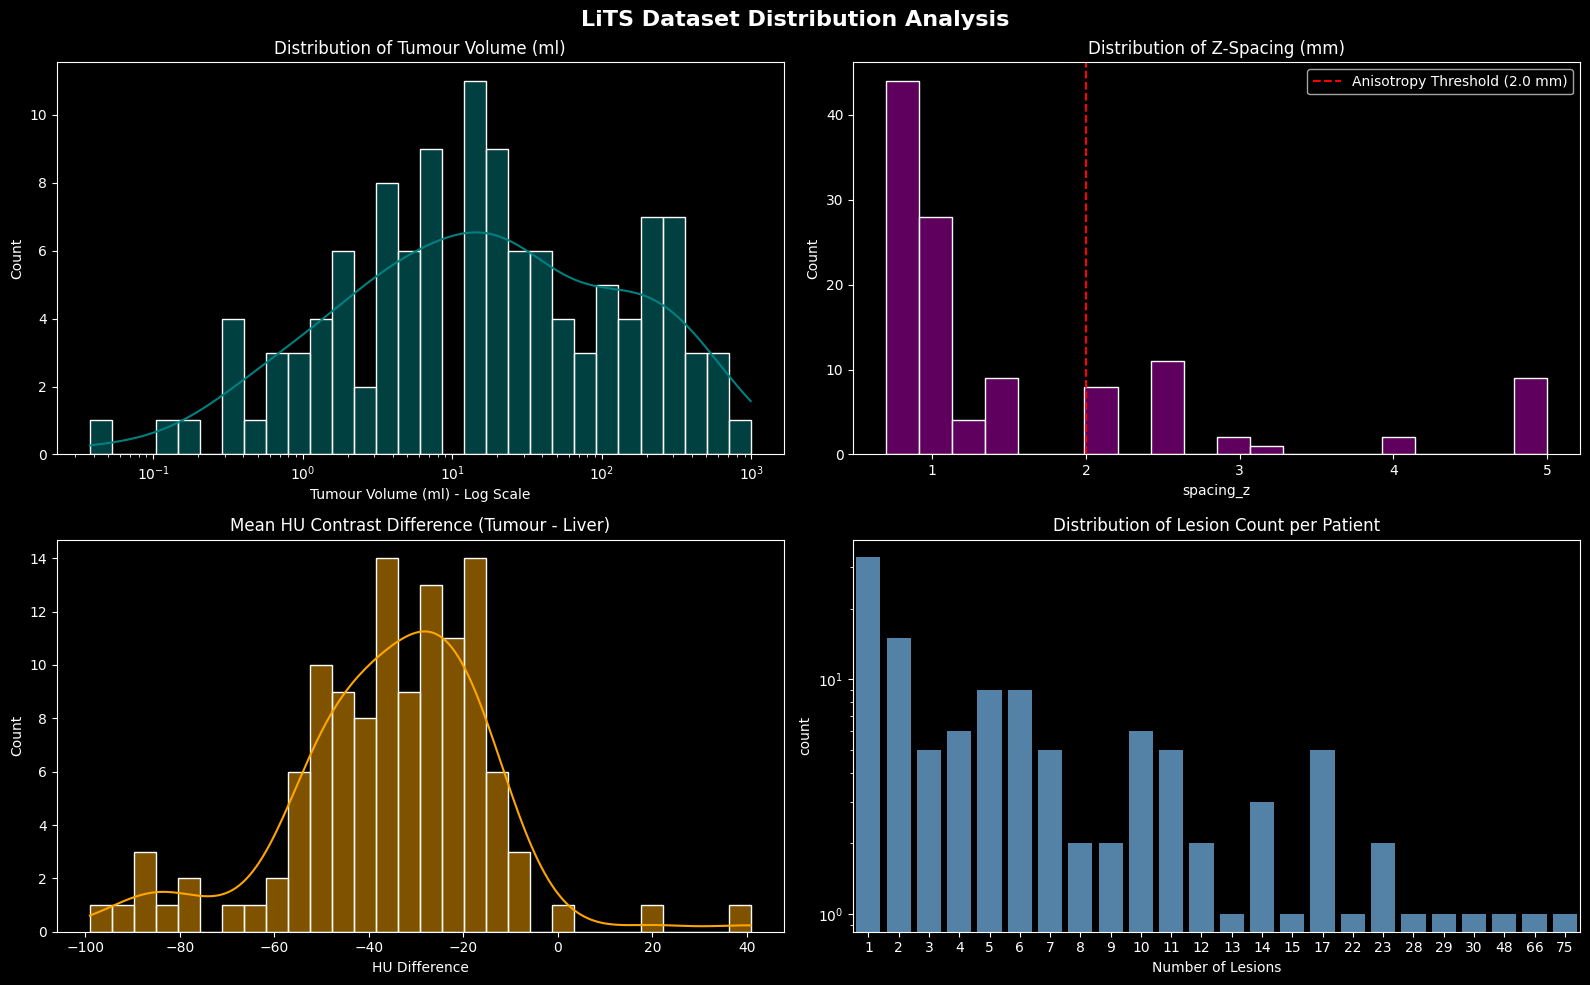

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LiTS Dataset Distribution Analysis', fontsize=16, fontweight='bold')

# A) Tumour Volume (Log scale is essential due to extreme right skew)
sns.histplot(data=all_w_tumour_filtered, x='tumour_volume_ml', log_scale=True, bins=30, ax=axes[0, 0], kde=True, color='teal')
axes[0, 0].set_title('Distribution of Tumour Volume (ml)')
axes[0, 0].set_xlabel('Tumour Volume (ml) - Log Scale')

# B) Z-Spacing (Resolution)
sns.histplot(data=all_w_tumour_filtered, x='spacing_z', bins=20, ax=axes[0, 1], color='purple')
axes[0, 1].set_title('Distribution of Z-Spacing (mm)')
axes[0, 1].axvline(2.0, color='red', linestyle='--', label='Anisotropy Threshold (2.0 mm)')
axes[0, 1].legend()

# C) HU Contrast Difference
sns.histplot(data=all_w_tumour_filtered, x='hu_contrast', bins=30, ax=axes[1, 0], kde=True, color='orange')
axes[1, 0].set_title('Mean HU Contrast Difference (Tumour - Liver)')
axes[1, 0].set_xlabel('HU Difference')

# D) Number of Lesions
sns.countplot(data=all_w_tumour_filtered, x='num_lesions', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_yscale('log')  # Log scale for counts as single-lesion cases dominate
axes[1, 1].set_title('Distribution of Lesion Count per Patient')
axes[1, 1].set_xlabel('Number of Lesions')

plt.tight_layout()
plt.show()

## Code

In [14]:
lits[lits['liver_hu_mean'] < 60]

,case_name,image_shape,label_shape,ct_min,ct_max,spacing_x,spacing_y,spacing_z,affine_codes,unique_labels,...,num_lesions,lesion_volumes_ml,lesion_equiv_diameters_mm,min_lesion_diameter_mm,max_lesion_diameter_mm,mean_lesion_diameter_mm,liver_texture_variance,liver_noise_estimate,status,obs
35,volume-13.nii.gz,"(512, 512, 605)","(512, 512, 605)",-1024.0,2302.0,0.847656,0.847656,1.0,"('L', 'A', 'S')",0;1;2,...,9,0.3693198547363281;0.14298570251464843;5.58937...,8.901598692567367;6.487808121936389;22.0185253...,2.965274,24.621623,11.999312,731.064498,22.962963,success,NaN
69,volume-43.nii.gz,"(512, 512, 155)","(512, 512, 155)",-1024.0,1023.0,1.000000,1.000000,1.0,"('R', 'A', 'S')",0;1;2,...,1,7.337,24.108672584252307,24.108673,24.108673,24.108673,1541.962802,31.111111,success,NaN
71,volume-45.nii.gz,"(512, 512, 74)","(512, 512, 74)",-1024.0,1023.0,1.000000,1.000000,1.0,"('R', 'A', 'S')",0;1;2,...,1,4.539,20.542526385937226,20.542526,20.542526,20.542526,517.566181,17.777778,success,NaN


Bins

In [15]:
# Bin spacing_z (CRITICAL)
def bin_spacing(z):
    if z <= 1.0: return 'thin'      # 0.7-1.0mm
    elif z <= 1.5: return 'medium'   # 1.25-1.5mm  
    else: return 'thick'             # >=2.0mm

# Bin liver HU (captures contrast phase)
def bin_liver_hu(hu):
    if hu < 60: return 'low'         # non-contrast/portal
    elif hu < 100: return 'mid'      # late arterial
    else: return 'high'              # early arterial

# Bin tumour volume (clinical difficulty)
def bin_tumor_vol(vol, has_tumor):
    if not has_tumor: return 'none'
    if vol < 5: return 'small'
    elif vol < 50: return 'medium'
    else: return 'large'

In [16]:
# Create composite key
lits['slice_group'] = lits['spacing_z'].apply(bin_spacing)
lits['liver_hu_group'] = lits['liver_hu_mean'].apply(bin_liver_hu)
lits['tumor_group'] = lits.apply(lambda r: bin_tumor_vol(r['tumour_volume_ml'], r['has_tumor']), axis=1)

lits['strat_key'] = (
    lits['slice_group'] + '_' + 
    lits['liver_hu_group'] + '_' + 
    lits['tumor_group']
)

In [17]:
lits['strat_key'].value_counts()

strat_key
thin_mid_medium      17
thin_high_large      17
thin_high_small      12
thin_high_medium      9
thin_high_none        8
thick_mid_medium      8
thick_high_medium     7
thin_mid_large        7
thin_mid_small        7
thick_mid_large       6
thick_high_small      5
thick_mid_small       5
thin_mid_none         4
medium_mid_small      4
medium_high_small     3
medium_mid_large      3
thin_low_medium       2
medium_high_large     2
thick_high_large      2
medium_mid_none       1
thin_low_small        1
medium_mid_medium     1
Name: count, dtype: int64

### Rare subgroup

There's a rare subgroup: Low HU (we only have 3 of such cases),
so we treat them independently to make sure we have 1 for the train, val and test
sets, while still ensuring a random choice.

In [18]:
# ==========================================
# 2. PRE-ALLOCATION OF RARE SUBGROUPS
# ==========================================
# Identify the rare subgroup
low_hu_mask = lits['liver_hu_mean'] < 60
low_hu_cases = lits[low_hu_mask].copy()
remaining_cases = lits[~low_hu_mask].copy()

print(f"Total cases: {len(lits)}")
print(f"Low HU cases separated: {len(low_hu_cases)}")
print(f"Remaining cases for stratification: {len(remaining_cases)}")

Total cases: 131
Low HU cases separated: 3
Remaining cases for stratification: 128


In [19]:
# Deterministically shuffle and assign 1 to each split
low_hu_shuffled = low_hu_cases.sample(frac=1, random_state=42).reset_index(drop=True)

pre_alloc_test = low_hu_shuffled.iloc[[0]]
pre_alloc_val  = low_hu_shuffled.iloc[[1]]
pre_alloc_train = low_hu_shuffled.iloc[[2]]

print(f"Pre-allocated to Test: {pre_alloc_test['case_name'].values[0]}")
print(f"Pre-allocated to Val:  {pre_alloc_val['case_name'].values[0]}")
print(f"Pre-allocated to Train: {pre_alloc_train['case_name'].values[0]}")

Pre-allocated to Test: volume-13.nii.gz
Pre-allocated to Val:  volume-43.nii.gz
Pre-allocated to Train: volume-45.nii.gz


In [20]:
# ==========================================
# 3. STRATIFY THE REMAINING DATA
# ==========================================
# Target totals: Train ~78, Val ~27, Test ~26 (Total 131)
# Since 1 is already in each, we need from the 128 remaining:
# Test: 25 | Val: 26 | Train: 77

mlb = MultiLabelBinarizer()
strat_labels_remaining = mlb.fit_transform(remaining_cases['strat_key'].apply(lambda x: [x]))

In [21]:
# First split: Train+Val (103) vs Test (25)
test_size_1 = 25 / len(remaining_cases)
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size_1, random_state=42)
train_val_idx, test_idx = next(msss1.split(remaining_cases, strat_labels_remaining))

remaining_train_val = remaining_cases.iloc[train_val_idx].copy()
remaining_test = remaining_cases.iloc[test_idx].copy()

In [22]:
# Second split: Train (77) vs Val (26)
test_size_2 = 26 / len(remaining_train_val)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size_2, random_state=42)
train_idx, val_idx = next(msss2.split(remaining_train_val, mlb.transform(remaining_train_val['strat_key'])))

remaining_train = remaining_train_val.iloc[train_idx]
remaining_val = remaining_train_val.iloc[val_idx]

/home/sonk/envs/dev-thesis/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['_', 'a', 'c', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'r', 's', 't', 'u'] will be ignored
  warnings.warn(


In [23]:
# ==========================================
# 4. RECOMBINE
# ==========================================
train = pd.concat([remaining_train, pre_alloc_train], ignore_index=True)
val = pd.concat([remaining_val, pre_alloc_val], ignore_index=True)
test = pd.concat([remaining_test, pre_alloc_test], ignore_index=True)

In [24]:
def print_stats(df, name):
    mean_vol = df[df['has_tumor']]['tumour_volume_ml'].mean()

    print(f"--- {name} Set ---")
    print(f"Total cases: {len(df)}")
    print(f"Cases without tumors: {(df['has_tumor'] == 0).sum()}")
    print(f"Cases with tumors: {(df['has_tumor'] == 1).sum()}")
    print(f"Tumour volume (mean ml): {mean_vol:.2f} ml")
    print(f"Liver HU (mean): {df['liver_hu_mean'].mean():.1f} HU")
    print("Stratification key distribution:")
    print("=== SPACING_Z DISTRIBUTION ===")
    print(f"  Thin (≤1.0mm): {(df['spacing_z'] <= 1.0).mean():.1%}")
    print(f"  Medium (1.25-1.5): {(df['spacing_z'].between(1.25, 1.5)).mean():.1%}")
    print(f"  Thick (≥2.0mm): {(df['spacing_z'] >= 2.0).mean():.1%}")

    print("\n")

print_stats(train, "Train")
print_stats(val, "Validation")
print_stats(test, "Test")

--- Train Set ---
Total cases: 79
Cases without tumors: 6
Cases with tumors: 73
Tumour volume (mean ml): 87.76 ml
Liver HU (mean): 100.7 HU
Stratification key distribution:
=== SPACING_Z DISTRIBUTION ===
  Thin (≤1.0mm): 62.0%
  Medium (1.25-1.5): 10.1%
  Thick (≥2.0mm): 26.6%


--- Validation Set ---
Total cases: 27
Cases without tumors: 4
Cases with tumors: 23
Tumour volume (mean ml): 120.31 ml
Liver HU (mean): 98.7 HU
Stratification key distribution:
=== SPACING_Z DISTRIBUTION ===
  Thin (≤1.0mm): 70.4%
  Medium (1.25-1.5): 7.4%
  Thick (≥2.0mm): 22.2%


--- Test Set ---
Total cases: 25
Cases without tumors: 3
Cases with tumors: 22
Tumour volume (mean ml): 47.30 ml
Liver HU (mean): 104.3 HU
Stratification key distribution:
=== SPACING_Z DISTRIBUTION ===
  Thin (≤1.0mm): 64.0%
  Medium (1.25-1.5): 12.0%
  Thick (≥2.0mm): 24.0%




In [25]:
def print_checks(df, name):
    print(f"--- {name} Set Checks ---")
    print(f"Unique stratification keys: {df['strat_key'].nunique()}")
    df_small = df[df['tumour_volume_ml'] < 5.0]
    print(f"Cases with small tumors (<5ml): {len(df_small)}")
    print(f"Volume range for small tumors: {df_small['tumour_volume_ml'].min():.2f} - {df_small['tumour_volume_ml'].max():.2f} ml")
    print("✅ Thick slices (≥2.0mm):", (df['spacing_z'] >= 2.0).sum())
    print("✅ Small tumours (<5 ml):", (df['tumour_volume_ml'] < 5).sum())
    print("✅ Multi-focal (≥5 lesions):", (df['num_lesions'] >= 5).sum())
    print("✅ Low liver HU (<60):", (df['liver_hu_mean'] < 60).sum())
    print("✅ Multi-focal (≥5 lesions):", (df['num_lesions'] >= 5).sum())
    print("✅ Low liver HU (<60):", (df['liver_hu_mean'] < 60).sum())
    print("\n")

print_checks(train, "Train")
print_checks(val, "Validation")
print_checks(test, "Test")


--- Train Set Checks ---
Unique stratification keys: 20
Cases with small tumors (<5ml): 31
Volume range for small tumors: 0.00 - 4.76 ml
✅ Thick slices (≥2.0mm): 21
✅ Small tumours (<5 ml): 31
✅ Multi-focal (≥5 lesions): 35
✅ Low liver HU (<60): 1
✅ Multi-focal (≥5 lesions): 35
✅ Low liver HU (<60): 1


--- Validation Set Checks ---
Unique stratification keys: 15
Cases with small tumors (<5ml): 9
Volume range for small tumors: 0.00 - 2.14 ml
✅ Thick slices (≥2.0mm): 6
✅ Small tumours (<5 ml): 9
✅ Multi-focal (≥5 lesions): 13
✅ Low liver HU (<60): 1
✅ Multi-focal (≥5 lesions): 13
✅ Low liver HU (<60): 1


--- Test Set Checks ---
Unique stratification keys: 17
Cases with small tumors (<5ml): 10
Volume range for small tumors: 0.00 - 4.34 ml
✅ Thick slices (≥2.0mm): 6
✅ Small tumours (<5 ml): 10
✅ Multi-focal (≥5 lesions): 11
✅ Low liver HU (<60): 1
✅ Multi-focal (≥5 lesions): 11
✅ Low liver HU (<60): 1




In [26]:
def generate_thesis_table_1(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Generates a publication-ready 'Table 1' comparing Train, Val, and Test splits.
    Uses Kruskal-Wallis for continuous (skewed) variables and Chi-square for categorical.
    """
    # 1. Prepare Data and add Split identifiers
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()
    
    train_label = f'Train (n={len(train_df)})'
    val_label = f'Val (n={len(val_df)})'
    test_label = f'Test (n={len(test_df)})'
    
    train_df['Split'] = train_label
    val_df['Split'] = val_label
    test_df['Split'] = test_label
    
    df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    
    # Bin spacing_z for Chi-square (requires discrete categories)
    def bin_spacing(z):
        if z <= 1.0: return 'Thin (<=1.0 mm)'
        elif z <= 1.5: return 'Medium (1.25-1.5 mm)'
        else: return 'Thick (>=2.0 mm)'
        
    df['Spacing Group'] = df['spacing_z'].apply(bin_spacing)
    
    # 2. Define Variables
    continuous_vars = {
        'Liver HU Mean (HU)': 'liver_hu_mean',
        'Liver Volume (ml)': 'liver_volume_ml',
        'Tumour Volume (ml)*': 'tumour_volume_ml',
        'Number of Lesions': 'num_lesions',
        'Liver Texture Variance': 'liver_texture_variance'
    }
    
    categorical_vars = {
        'Has Tumour': 'has_tumor',
        'Slice Thickness Group': 'Spacing Group'
    }
    
    # 3. Statistical Analysis and Formatting
    print(f"{'Variable':<25} | {train_label:<22} | {val_label:<22} | {test_label:<22} | {'p-value':<10}")
    print("-" * 120)
    
    # --- Continuous Variables (Median [IQR], Kruskal-Wallis) ---
    for label, col in continuous_vars.items():
        # Drop NaNs (e.g., tumour_volume_ml might be NaN if has_tumor is False)
        t = train_df[col].dropna()
        v = val_df[col].dropna()
        te = test_df[col].dropna()
        
        def get_median_iqr(s):
            if len(s) == 0: return "N/A"
            return f"{s.median():.2f} [{s.quantile(0.25):.2f}-{s.quantile(0.75):.2f}]"
            
        t_str = get_median_iqr(t)
        v_str = get_median_iqr(v)
        te_str = get_median_iqr(te)
        
        # Kruskal-Wallis H-test
        if len(t) > 0 and len(v) > 0 and len(te) > 0:
            stat, p_val = kruskal(t, v, te)
            p_str = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
        else:
            p_str = "N/A"
            
        print(f"{label:<25} | {t_str:<22} | {v_str:<22} | {te_str:<22} | {p_str:<10}")
        
    print("-" * 120)
    
    # --- Categorical Variables (N (%), Chi-square) ---
    for label, col in categorical_vars.items():
        # Create contingency table
        ct = pd.crosstab(df[col], df['Split'])
        
        # Ensure all splits are present in columns
        for split_col in [train_label, val_label, test_label]:
            if split_col not in ct.columns:
                ct[split_col] = 0
        ct = ct[[train_label, val_label, test_label]]
                 
        # Chi-square test
        chi2, p_val, dof, expected = chi2_contingency(ct)
        p_str = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
        
        print(f"{label:<25} | {'':<22} | {'':<22} | {'':<22} | {p_str:<10}")
        
        # Print each category
        for cat in ct.index:
            t_n = ct.loc[cat, train_label]
            v_n = ct.loc[cat, val_label]
            te_n = ct.loc[cat, test_label]
            
            t_pct = (t_n / len(train_df)) * 100
            v_pct = (v_n / len(val_df)) * 100
            te_pct = (te_n / len(test_df)) * 100
            
            cat_str = f"  {str(cat)}"
            t_fmt = f"{t_n} ({t_pct:.1f}%)"
            v_fmt = f"{v_n} ({v_pct:.1f}%)"
            te_fmt = f"{te_n} ({te_pct:.1f}%)"
            
            print(f"{cat_str:<25} | {t_fmt:<22} | {v_fmt:<22} | {te_fmt:<22} | {'':<10}")

    print("-" * 120)
    print("* Tumour Volume calculated only for cases where has_tumor == True")
    print("\nNote: A p-value > 0.05 indicates no statistically significant difference between the splits,")
    print("proving that your stratification successfully balanced the dataset.")

In [27]:
generate_thesis_table_1(train, val, test)

Variable                  | Train (n=79)           | Val (n=27)             | Test (n=25)            | p-value   
------------------------------------------------------------------------------------------------------------------------
Liver HU Mean (HU)        | 98.47 [89.74-113.16]   | 102.38 [84.97-110.00]  | 98.36 [92.62-115.52]   | 0.705     
Liver Volume (ml)         | 1587.14 [1366.78-1804.05] | 1712.22 [1454.28-1971.79] | 1470.00 [1251.93-1746.73] | 0.081     
Tumour Volume (ml)*       | 14.40 [2.33-53.37]     | 20.32 [1.55-133.17]    | 8.38 [0.66-39.48]      | 0.451     
Number of Lesions         | 3.00 [1.00-7.00]       | 4.00 [1.00-10.50]      | 2.00 [1.00-9.00]       | 0.762     
Liver Texture Variance    | 754.63 [563.15-955.19] | 996.71 [654.98-1311.61] | 761.77 [475.85-994.92] | 0.178     
------------------------------------------------------------------------------------------------------------------------
Has Tumour                |                        |            

## Generate the new stratification files

### CSV files

In [38]:
train.to_csv("../files/stats/lits/stratified_train.csv", index=False)
val.to_csv("../files/stats/lits/stratified_val.csv", index=False)
test.to_csv("../files/stats/lits/stratified_test.csv", index=False)

### JSON split

In [ ]:
def save_stratification_metadata(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, output_path: str):
    """
    Generates and saves the stratification metadata to a JSON file 
    using the pre-computed stratification keys present in the dataframes.
    Excludes the test set as this file is used for training pipeline configuration.
    """
    
    # 1. Build the 'bins' dictionary mapping composite keys to case lists
    bins = {}
    for df in [train_df, val_df, test_df]:
        for key, group in df.groupby('strat_key'):
            if key not in bins:
                bins[key] = []
            bins[key].extend(group['case_name'].tolist())

    # Sort bins and file lists for readability and deterministic output
    bins = {k: sorted(v) for k, v in sorted(bins.items())}

    # 2. Construct the final JSON payload
    metadata = {
        "creation_date": datetime.datetime.now().isoformat(),
        "stratification_method": "iterative_multilabel_with_pre_allocation",
        "stratified_by": "composite_key (slice_group + liver_hu_group + tumor_group)",
        "pre_allocation_rule": "Cases with liver_hu_mean < 60 were deterministically pre-allocated (1 to train, 1 to val, 1 to test) prior to iterative stratification to guarantee rare protocol representation.",
        "train": sorted(train_df['case_name'].tolist()),
        "val": sorted(val_df['case_name'].tolist()),
        "test": sorted(test_df['case_name'].tolist()),
        "bins": bins
    }
    
    # 3. Save to disk
    out_path = Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(out_path, 'w') as f:
        json.dump(metadata, f, indent=2)
        
    print(f"Stratification metadata successfully saved to {out_path.resolve()}")

In [29]:
save_stratification_metadata(train, val, "../files/splits/stratification_metadata.json")

Stratification metadata successfully saved to /home/sonk/Devel/master/thesis/pininos/files/splits/stratification_metadata.json
